In [1]:
import numpy as np
import matplotlib.pyplot as plt
import colormaps as cmaps

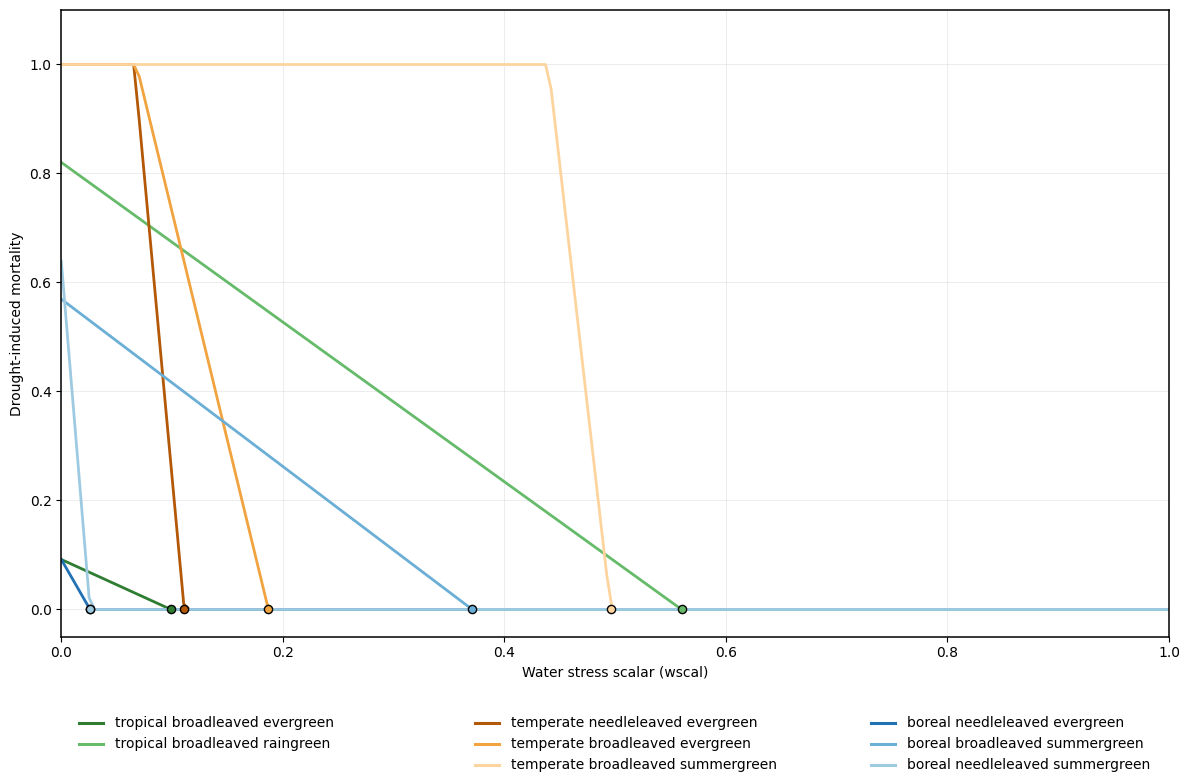

In [2]:
import numpy as np
import matplotlib.pyplot as plt

wscal = np.linspace(0, 1, 200)

pfts = {
    "tropical broadleaved evergreen": (0.099, 0.927),
    "tropical broadleaved raingreen": (0.560, 1.465),
    "temperate needleleaved evergreen": (0.111, 22.103),
    "temperate broadleaved evergreen": (0.187, 8.386),
    "temperate broadleaved summergreen": (0.496, 17.755),
    "boreal needleleaved evergreen": (0.026, 3.534),
    "boreal broadleaved summergreen": (0.371, 1.535),
    "boreal needleleaved summergreen": (0.026, 24.583),
}

tropical_colors = ["#2e7d32", "#66bb6a"]
temperate_colors = ["#b35806", "#f1a340", "#fdd49e"]
boreal_colors = ["#2171b5", "#6baed6", "#9ecae1"]

color_map = {
    "tropical broadleaved evergreen": tropical_colors[0],
    "tropical broadleaved raingreen": tropical_colors[1],

    "temperate needleleaved evergreen": temperate_colors[0],
    "temperate broadleaved evergreen": temperate_colors[1],
    "temperate broadleaved summergreen": temperate_colors[2],

    "boreal needleleaved evergreen": boreal_colors[0],
    "boreal broadleaved summergreen": boreal_colors[1],
    "boreal needleleaved summergreen": boreal_colors[2],
}

plt.figure(figsize=(12, 7))
ax = plt.gca()

for name, (alpha, beta) in pfts.items():

    mortality = np.clip((alpha - wscal) * beta, 0, 1)
    color = color_map[name]

    ax.plot(
        wscal,
        mortality,
        color=color,
        linewidth=2, label=name
    )

    # mark α threshold (no vertical line)
    ax.scatter(alpha, 0, color=color, edgecolor="black", zorder=5, s=35)

    # direct label
    label = name.replace("broadleaved", "BL") \
                .replace("needleleaved", "NL") \
                .replace("summergreen", "SG") \
                .replace("evergreen", "EV") \
                .replace("raingreen", "RG")

    # ax.text(
    #     1.01,
    #     mortality[-1],
    #     label,
    #     color=color,
    #     fontsize=10,
    #     va="center"
    # )

# axes
ax.set_xlabel("Water stress scalar (wscal)")
ax.set_ylabel("Drought-induced mortality")

ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.1)

ax.grid(True, linewidth=0.4, alpha=0.4)

for spine in ax.spines.values():
    spine.set_linewidth(1.1)
    
    
import matplotlib.lines as mlines

handles, labels = plt.gca().get_legend_handles_labels()

# your desired layout:
layout = [
    [0, 2, 5],
    [1, 3, 6],
    [None, 4, 7]
]

fig = plt.gcf()
ax = plt.gca()

# position of custom legend block (figure coordinates)
x0, y0 = 0.07, -0.04
dx, dy = 0.33, 0.03

for r, row in enumerate(layout):
    for c, idx in enumerate(row):
        if idx is None:
            continue
        
        line = handles[idx]
        label = labels[idx]

        # draw line sample
        fig.lines.append(
            mlines.Line2D(
                [x0 + c*dx, x0 + c*dx + 0.02],
                [y0 - r*dy, y0 - r*dy],
                transform=fig.transFigure,
                color=line.get_color(),
                linewidth=2.2
            )
        )

        # draw text
        fig.text(
            x0 + c*dx + 0.03,
            y0 - r*dy,
            label,
            fontsize=10,
            va="center"
        )

plt.tight_layout()
plt.savefig(
    "2026_06_01_wscal_vs_mort_theoretical.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

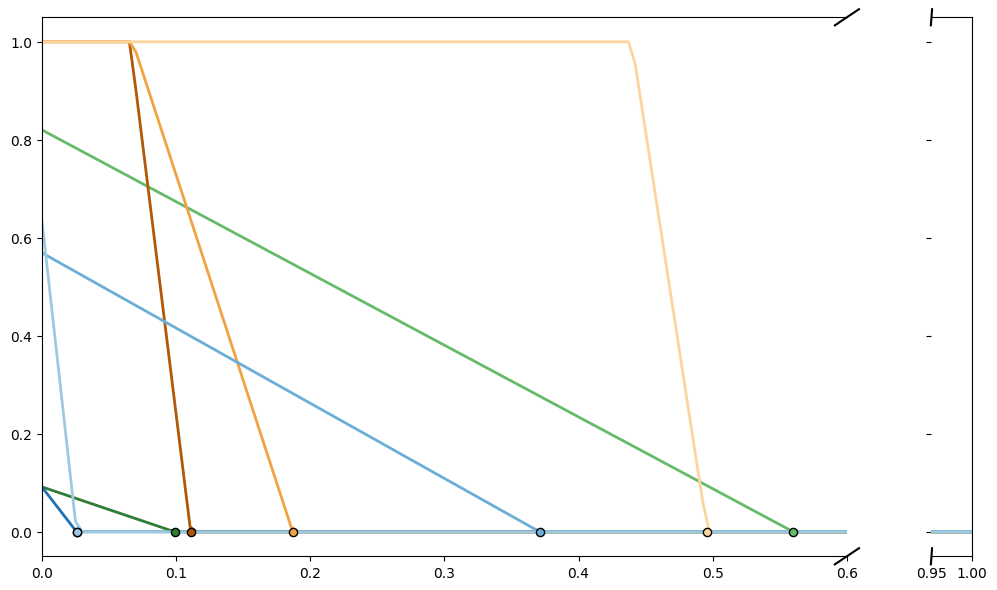

In [6]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    sharey=True,
    figsize=(12, 7),
    gridspec_kw={'width_ratios': [20, 1]}
)

for name, (alpha, beta) in pfts.items():
    mortality = np.clip((alpha - wscal) * beta, 0, 1)
    color = color_map[name]

    ax1.plot(wscal, mortality, color=color, lw=2)
    ax2.plot(wscal, mortality, color=color, lw=2)
    ax1.scatter(alpha, 0, color=color, edgecolor="black", zorder=5, s=35)

# limits
ax1.set_xlim(0, 0.6)
ax2.set_xlim(0.95, 1.0)

# hide spines between plots
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# diagonal break marks
d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

/scratch-local/77370/ipykernel_1781641/1973157831.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


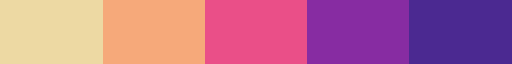

In [17]:
def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0, 1, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap_discrete = create_discrete_colormap(cmaps.agsunset_r, 5)
cmap_discrete

/scratch-local/77370/ipykernel_1781641/3138939612.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_continuous = plt.cm.get_cmap(cmap)


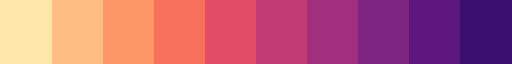

In [37]:
def create_discrete_colormap(cmap, num_colors):
    cmap_continuous = plt.cm.get_cmap(cmap)
    colors_continuous = cmap_continuous(np.linspace(0.05, 0.8, num_colors))  # Adjusted range, excluding white
    cmap_discrete = plt.matplotlib.colors.ListedColormap(colors_continuous)
    return cmap_discrete

# Example usage:
cmap_discrete = create_discrete_colormap("magma_r", 10)
cmap_discrete.set_bad(color="white")
cmap_discrete

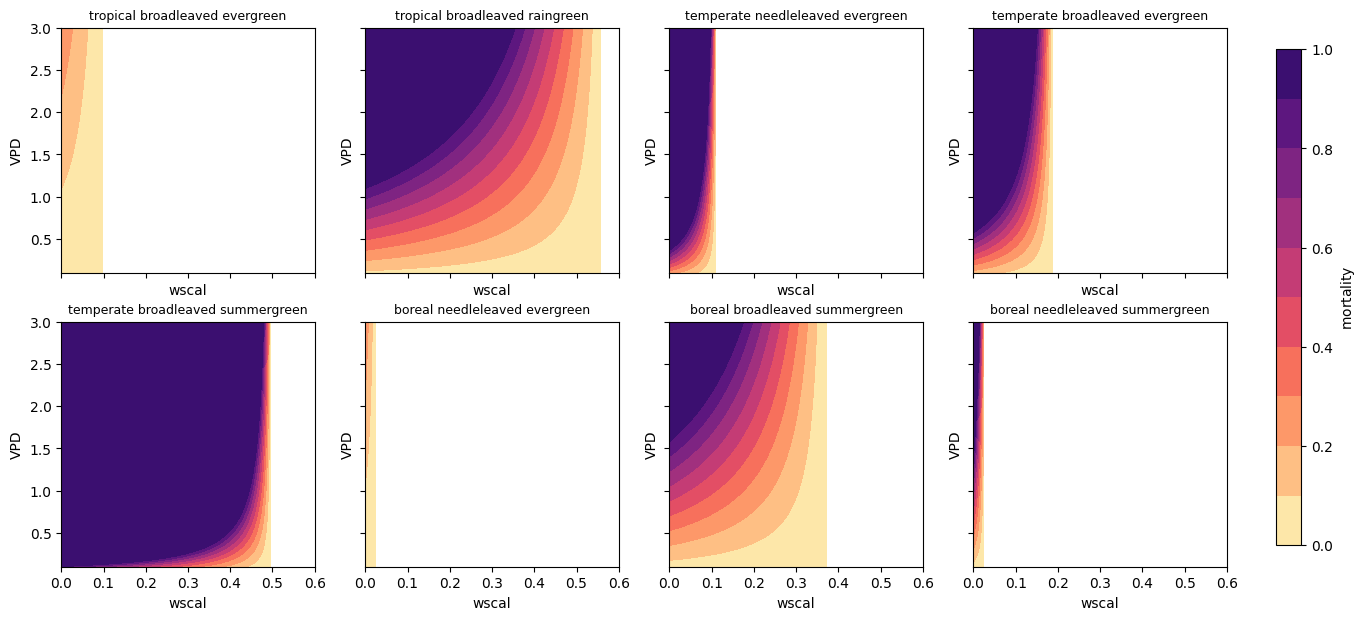

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# axes
# ----------------------------
wscal = np.linspace(0, 0.6, 200)
vpd = np.linspace(0.1, 3.0, 200)

W, V = np.meshgrid(wscal, vpd)


# ----------------------------
# figure layout
# ----------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (name, (alpha, beta)) in zip(axes, pfts.items()):

    # ----------------------------
    # model (NO clipping, NO epsilon)
    # ----------------------------
    mortality = np.clip((alpha - W) * V * beta, 0, 1)

    # log transform (NaNs allowed if mortality=0 or invalid)
    Z = np.ma.masked_where(mortality == 0, mortality)

    # mask NaNs so plot doesn't break
    Z_masked = np.ma.masked_invalid(Z)
    vmin = 0
    vmax = 1
    levels = np.linspace(vmin, vmax, 11)

    im = ax.contourf(W, V, Z_masked, levels=levels, cmap=cmap_discrete)

    ax.set_title(name, fontsize=9)
    ax.set_xlabel("wscal")
    ax.set_ylabel("VPD")

# ----------------------------
# colorbar
# ----------------------------
cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
cbar.set_label(r"$\mathrm{mortality}$")

# plt.tight_layout()
plt.savefig(
    "/home/druijsch/scripts/2026_06_01_theoretical_wscal_vs_mort/2026_06_01_wscal_vs_mort_theoretical_withVPD.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

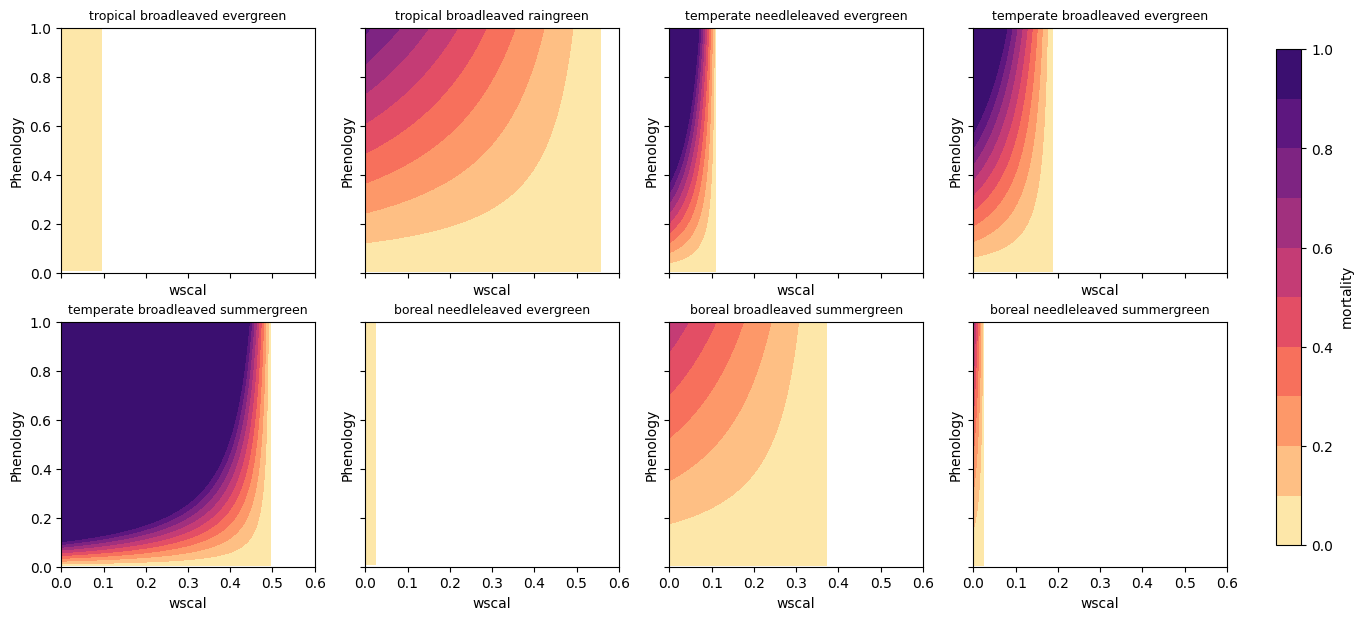

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# axes
# ----------------------------
wscal = np.linspace(0, 0.6, 200)
vpd = np.linspace(0.1, 3.0, 200)
phenology = np.linspace(0, 1, 200)

W, P = np.meshgrid(wscal, phenology)


# ----------------------------
# figure layout
# ----------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (name, (alpha, beta)) in zip(axes, pfts.items()):

    # ----------------------------
    # model (NO clipping, NO epsilon)
    # ----------------------------
    mortality = np.clip((alpha - W) * P * beta, 0, 1)

    # log transform (NaNs allowed if mortality=0 or invalid)
    Z = np.ma.masked_where(mortality == 0, mortality)
    
    # mask NaNs so plot doesn't break
    Z_masked = np.ma.masked_invalid(Z)
    vmin = 0  # example
    vmax = 1    # because log10(mortality) ≤ 0 for (0,1)
    levels = np.linspace(vmin, vmax, 11)

    im = ax.contourf(W, P, Z_masked, levels=levels, cmap=cmap_discrete)

    ax.set_title(name, fontsize=9)
    ax.set_xlabel("wscal")
    ax.set_ylabel("Phenology")

# ----------------------------
# colorbar
# ----------------------------
cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
cbar.set_label(r"$\mathrm{mortality}$")
plt.savefig(
    "/home/druijsch/scripts/2026_06_01_theoretical_wscal_vs_mort/2026_06_01_wscal_vs_mort_theoretical_withPHEN.png",
    dpi=300,
    bbox_inches="tight"
)
# plt.tight_layout()
plt.show()